In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sn
import matplotlib

In [3]:
data_folder = 'E:/FINAL VERIFICATION/'

chainsaw_positive = pd.read_csv(data_folder + 'CHAINSAW_Positive_detections_addLocation.csv')
chainsaw_negative = pd.read_csv(data_folder + 'CHAINSAW_Negative_detections_addLocation.csv')

gibbon_positive = pd.read_csv(data_folder + 'LARGIBBON_Positive_detections_addLocation.csv')
gibbon_negative = pd.read_csv(data_folder + 'LARGIBBON_Negative_detections_addLocation.csv')

siamang_positive = pd.read_csv(data_folder + 'SIAMANG_Positive_detections_addLocation.csv')
siamang_negative = pd.read_csv(data_folder + 'SIAMANG_Negative_detections_addLocation.csv')


In [5]:
detections = pd.concat((chainsaw_positive, gibbon_positive, siamang_positive))

In [7]:
detections['Species'].value_counts()

Species
CHAINSAW     30417
SIAMANG      24392
LARGIBBON     6642
Name: count, dtype: int64

In [9]:
detections.head()

,Species,Deployment,Unit,Filename,Date,Start Time,End Time,Confidence,Positive or Negative,Point Name,LAT [decimal degrees],LON [decimal degrees],Y_PROJ,X_PROJ,First file date [UTC],Last file date [UTC],Total Days
0,CHAINSAW,DEP 1,Unit002,0.900_118_Unit002_20220901_092004_2073.0s_2076...,2022-09-01,2022-09-01 09:54:37,2022-09-01 09:54:40,0.900,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29
1,CHAINSAW,DEP 1,Unit002,0.900_44_Unit002_20220901_092004_1923.0s_1926....,2022-09-01,2022-09-01 09:52:07,2022-09-01 09:52:10,0.900,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29
2,CHAINSAW,DEP 1,Unit002,0.901_289_Unit002_20220920_104004_3036.0s_3039...,2022-09-20,2022-09-20 11:30:40,2022-09-20 11:30:43,0.901,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29
3,CHAINSAW,DEP 1,Unit002,0.901_30_Unit002_20220829_144005_2022.0s_2025....,2022-08-29,2022-08-29 15:13:47,2022-08-29 15:13:50,0.901,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29
4,CHAINSAW,DEP 1,Unit002,0.901_388_Unit002_20220901_092004_1023.0s_1026...,2022-09-01,2022-09-01 09:37:07,2022-09-01 09:37:10,0.901,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29


In [11]:
detections['Deployment'].value_counts()

Deployment
DEP 2    22094
DEP 1     9595
DEP 7     6802
DEP 4     6347
DEP 9     5237
DEP 8     4813
DEP 5     3093
DEP 6     2594
DEP 3      876
Name: count, dtype: int64

In [13]:
detections['Start Time'] = detections['Start Time'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d %H:%M:%S'))
detections['Date'] = detections['Start Time'].apply(lambda x: x.date())
detections['Hour'] = detections['Start Time'].dt.hour

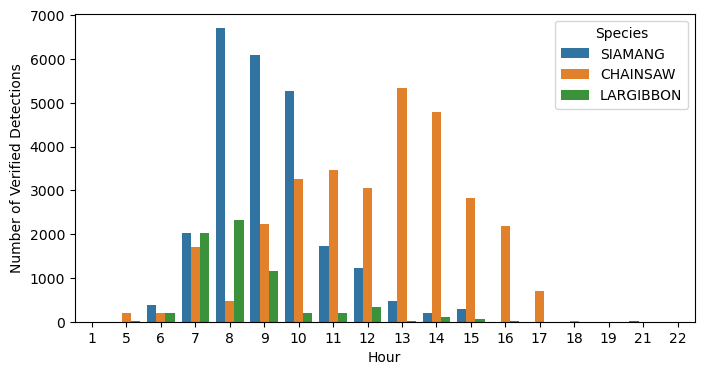

In [15]:
plt.figure(figsize=(8, 4))
sn.countplot(detections, x = 'Hour', hue='Species')
plt.ylabel('Number of Verified Detections')
plt.savefig('E:/FINAL VERIFICATION/verified_detections_hourly_plot.png', dpi=200)

Text(0, 0.5, 'Number of Verified Detections')

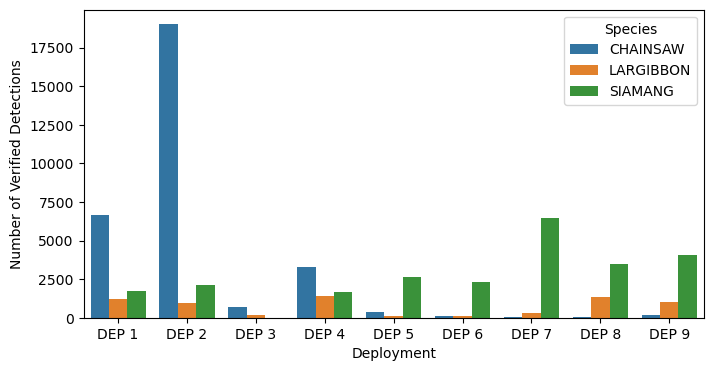

In [17]:
plt.figure(figsize=(8, 4))
sn.countplot(detections, x = 'Deployment', hue='Species')
plt.ylabel('Number of Verified Detections')
#plt.savefig('/Users/ivt2/Documents/2025/Jun/figures/verified_detections_counts_by_dep.png', dpi=200)

Text(0, 0.5, 'Number of Verified Detections')

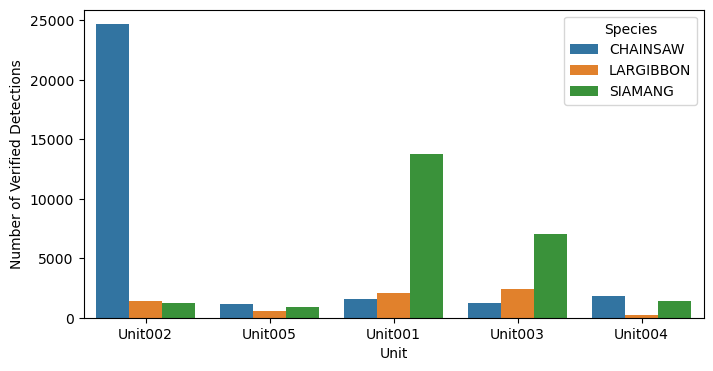

In [19]:
plt.figure(figsize=(8, 4))
sn.countplot(detections, x = 'Unit', hue='Species')
plt.ylabel('Number of Verified Detections')
#plt.savefig('/Users/ivt2/Documents/2025/Jun/figures/verified_detections_counts_by_unit.png', dpi=200)

In [21]:
def dielPlot(data, deployment = None, vmaxes=None):
    title_label = 'All Deployments'

    if deployment is not None:
        data = data[data['Deployment'] == deployment]
        title_label = deployment
    
    # get start and end days
    start_date = np.min(data['Date'])
    end_date = np.max(data['Date'])

    # then make a list for all days and hours
    survey_hours = np.arange(24)
    survey_dates = pd.date_range(start_date, end_date, freq='D')

    print(start_date, end_date)

    species_counts = {}

    for species in ['CHAINSAW', 'LARGIBBON', 'SIAMANG']:
        # count the number of detections for each hour and day
        species_counts[species] = np.zeros((len(survey_dates), len(survey_hours)))
        species_data = data[data['Species'] == species]

        for d in range(len(survey_dates)):
            for h in range(len(survey_hours)):
                date_match = species_data[species_data['Date'] == survey_dates[d].date()]
                hour_match = date_match[date_match['Hour'] == survey_hours[h]]
                species_counts[species][d, h] = len(hour_match)
    
    if (deployment is None):
        fig, ax = plt.subplots(1, 3, figsize=(14, 12))
    else:
        fig, ax = plt.subplots(1, 3, figsize=(14, 8))
    cmap = plt.cm.Purples
    #cmap = plt.cm.viridis
    cmap.set_under('darkblue')

    for i, species in enumerate(['CHAINSAW', 'LARGIBBON', 'SIAMANG']):
        plt.subplot(1, 3, i+1)
        if vmaxes is not None:
            pcol = plt.pcolormesh(survey_hours, survey_dates, species_counts[species], cmap=cmap, norm=matplotlib.colors.LogNorm(vmin=1))
        else:
            pcol = plt.pcolormesh(survey_hours, survey_dates, species_counts[species], cmap=cmap)
        plt.colorbar(orientation='horizontal', pad=0.1)

        ax[i].yaxis.set_major_locator(mdates.MonthLocator())
        ax[i].yaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

        plt.title('%s (%s)' % (species,title_label), fontsize=14)
        plt.xlabel('Hour', fontsize=16)
        if (i == 0):
            plt.ylabel('Date', fontsize=16)
    
    plt.tight_layout()

In [23]:
detections[detections['Deployment'] == 'DEP 1']

,Species,Deployment,Unit,Filename,Date,Start Time,End Time,Confidence,Positive or Negative,Point Name,LAT [decimal degrees],LON [decimal degrees],Y_PROJ,X_PROJ,First file date [UTC],Last file date [UTC],Total Days,Hour
0,CHAINSAW,DEP 1,Unit002,0.900_118_Unit002_20220901_092004_2073.0s_2076...,2022-09-01,2022-09-01 09:54:37,2022-09-01 09:54:40,0.900,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,9
1,CHAINSAW,DEP 1,Unit002,0.900_44_Unit002_20220901_092004_1923.0s_1926....,2022-09-01,2022-09-01 09:52:07,2022-09-01 09:52:10,0.900,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,9
2,CHAINSAW,DEP 1,Unit002,0.901_289_Unit002_20220920_104004_3036.0s_3039...,2022-09-20,2022-09-20 11:30:40,2022-09-20 11:30:43,0.901,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,11
3,CHAINSAW,DEP 1,Unit002,0.901_30_Unit002_20220829_144005_2022.0s_2025....,2022-08-29,2022-08-29 15:13:47,2022-08-29 15:13:50,0.901,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,15
4,CHAINSAW,DEP 1,Unit002,0.901_388_Unit002_20220901_092004_1023.0s_1026...,2022-09-01,2022-09-01 09:37:07,2022-09-01 09:37:10,0.901,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,SIAMANG,DEP 1,Unit001,1.000_9_Unit001_20220830_104004_678.0s_681.0s.wav,2022-08-30,2022-08-30 10:51:22,2022-08-30 10:51:25,1.000,Positive,LL 500,3.963205,98.063380,438118.9347,396020.6201,8/24/2022,9/21/2022,28,10
1732,SIAMANG,DEP 1,Unit001,1.000_9_Unit001_20220908_144005_1965.0s_1968.0...,2022-09-08,2022-09-08 15:12:50,2022-09-08 15:12:53,1.000,Positive,LL 500,3.963205,98.063380,438118.9347,396020.6201,8/24/2022,9/21/2022,28,15
1733,SIAMANG,DEP 1,Unit001,1.000_9_Unit001_20220909_092003_2130.0s_2133.0...,2022-09-09,2022-09-09 09:55:33,2022-09-09 09:55:36,1.000,Positive,LL 500,3.963205,98.063380,438118.9347,396020.6201,8/24/2022,9/21/2022,28,9
1734,SIAMANG,DEP 1,Unit002,1.000_9_Unit002_20220903_080003_1836.0s_1839.0...,2022-09-03,2022-09-03 08:30:39,2022-09-03 08:30:42,1.000,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,8


2022-08-24 2022-09-21
2022-09-22 2022-10-23
2022-10-26 2022-11-18
2022-11-24 2023-01-08
2023-02-08 2023-03-07
2023-03-09 2023-04-08
2023-04-11 2023-05-21
2023-05-22 2023-06-04
2023-07-15 2023-08-31


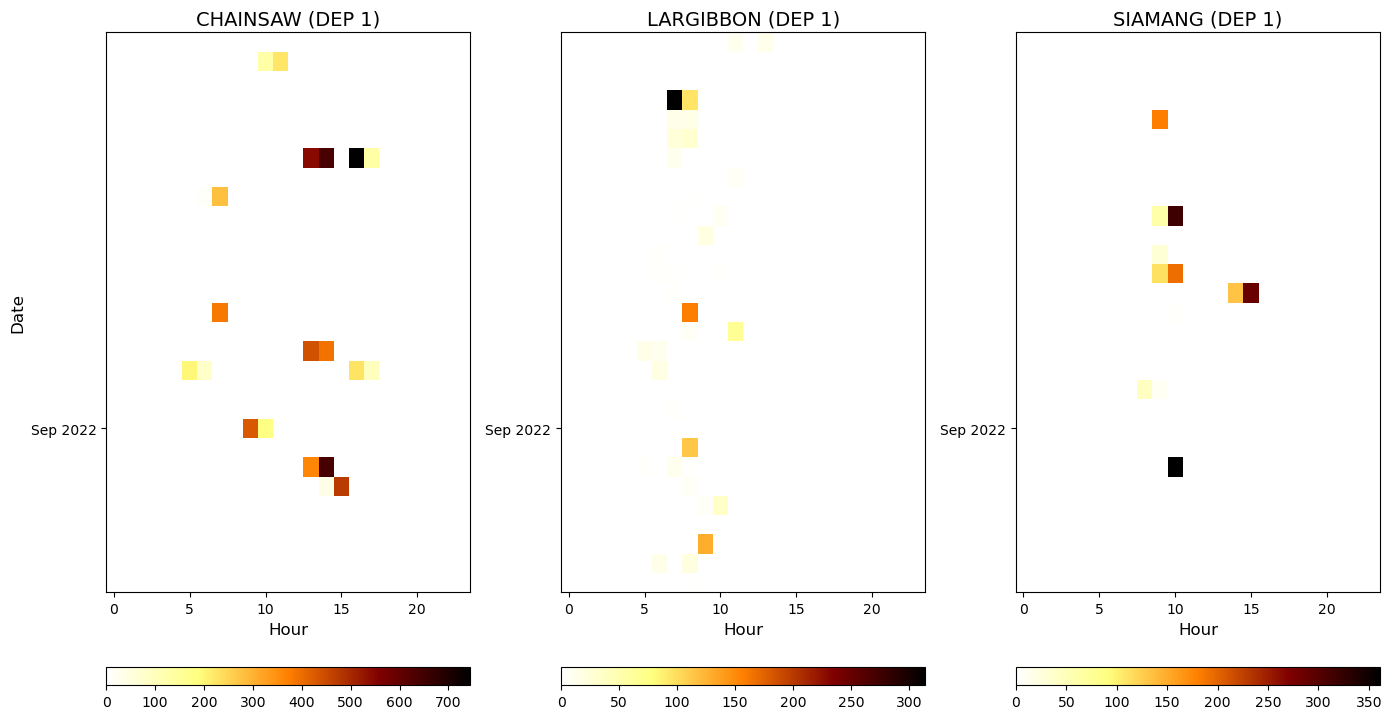

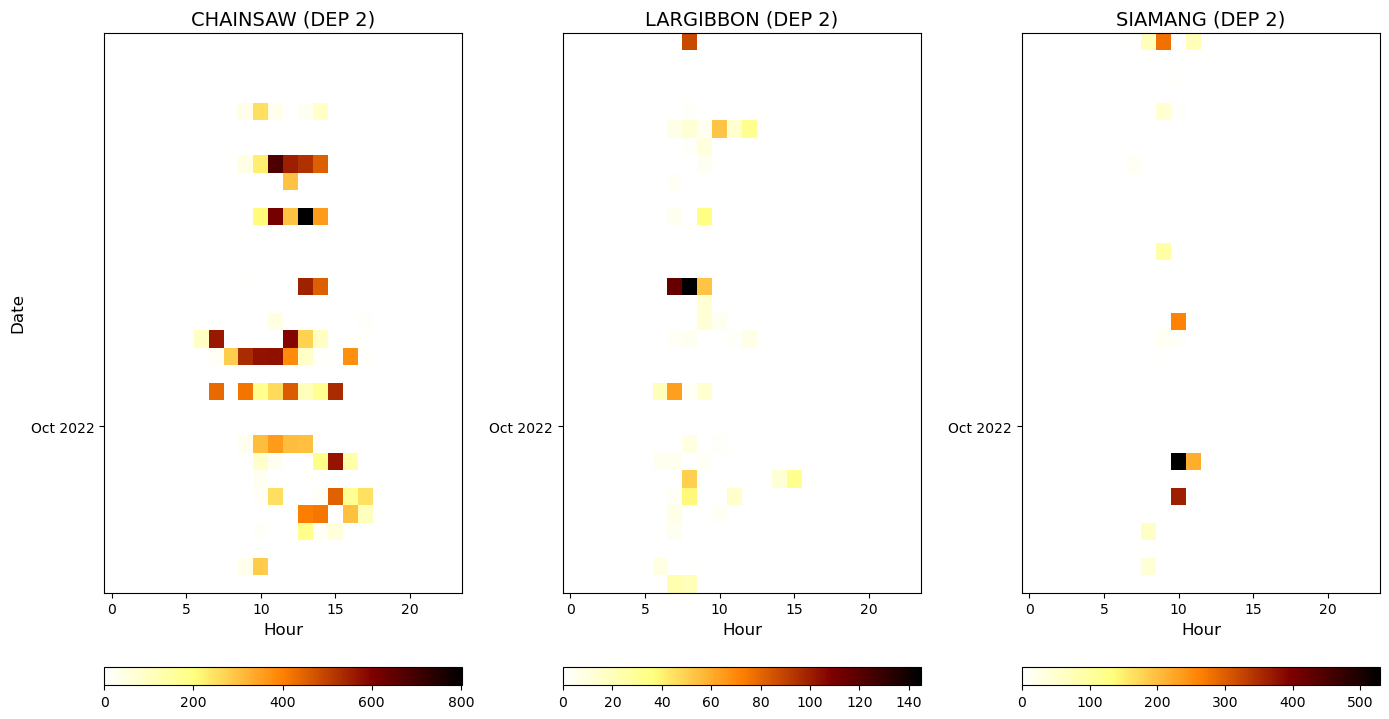

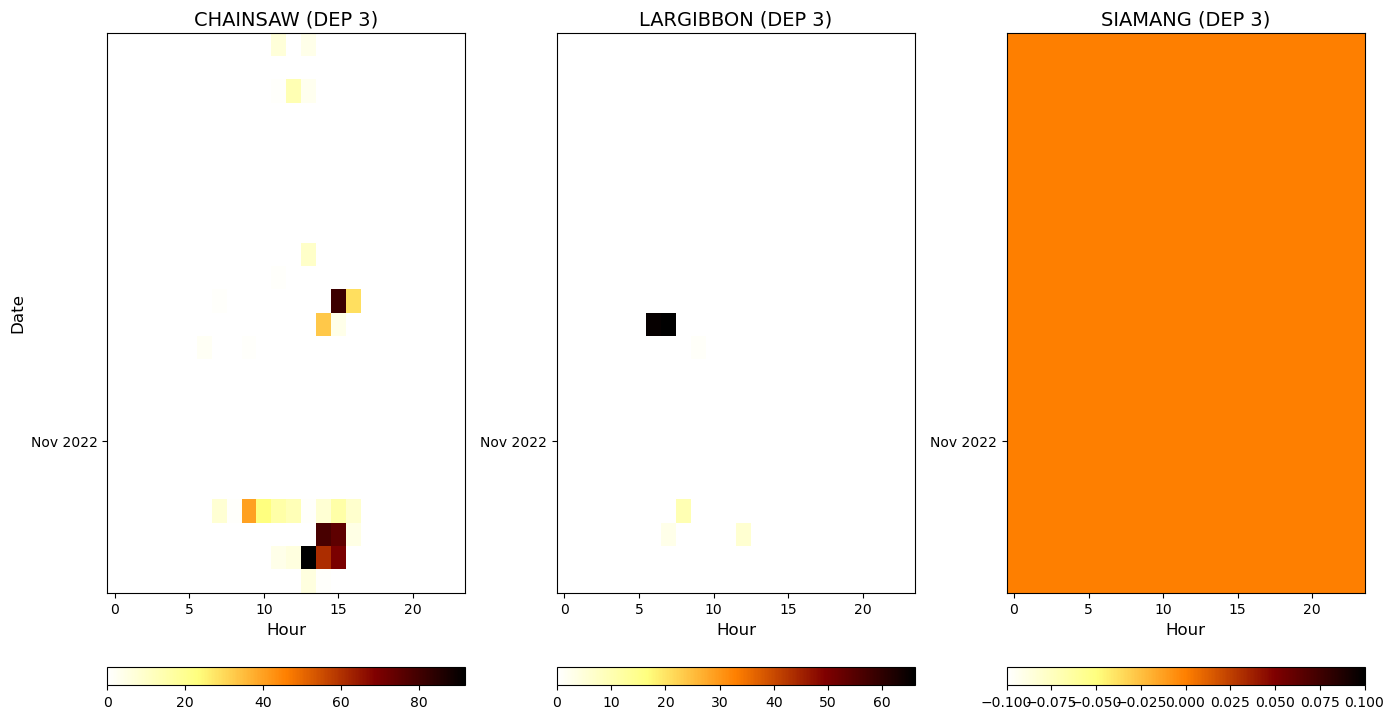

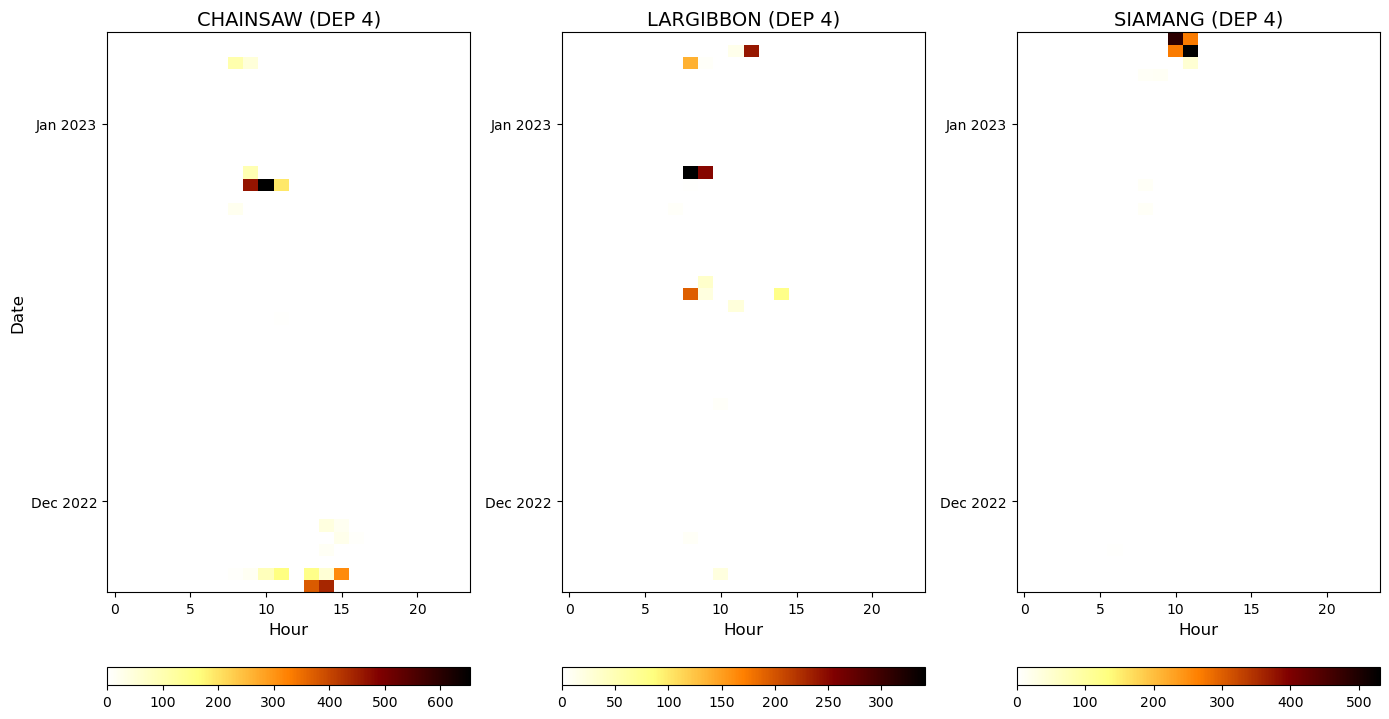

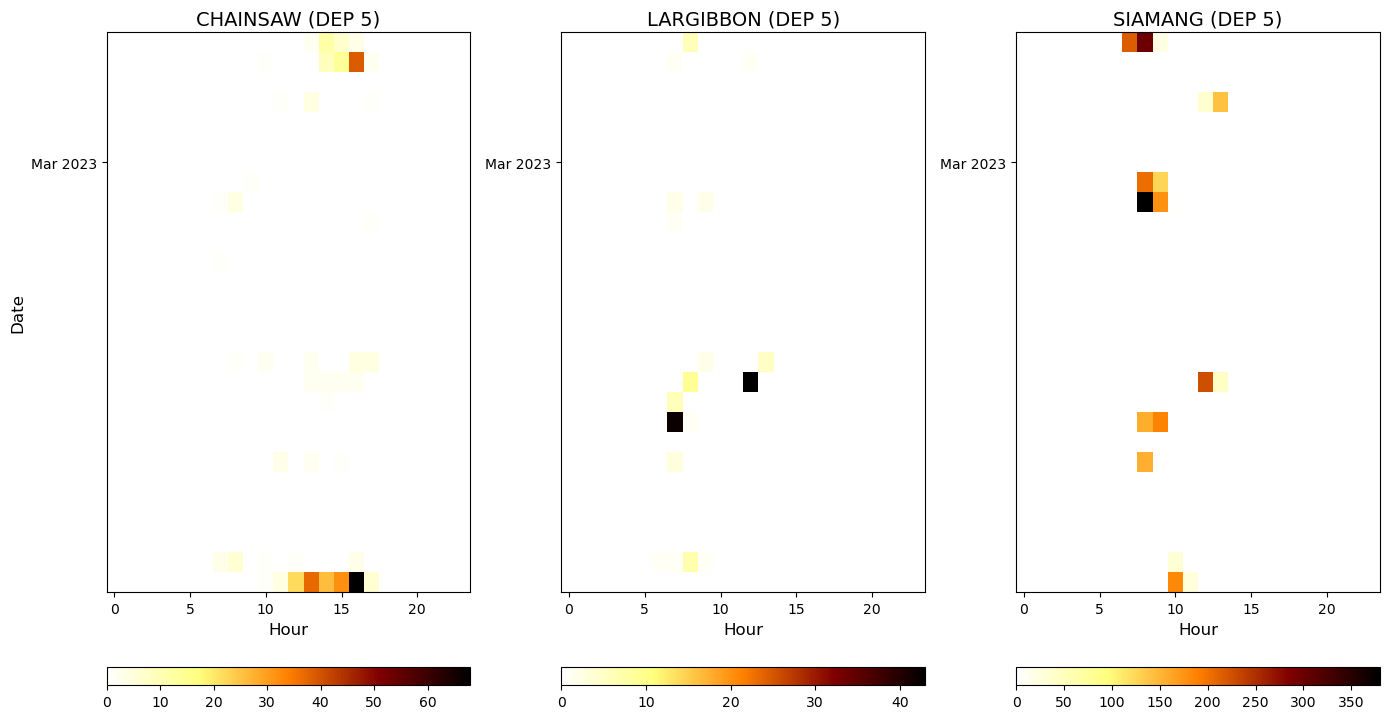

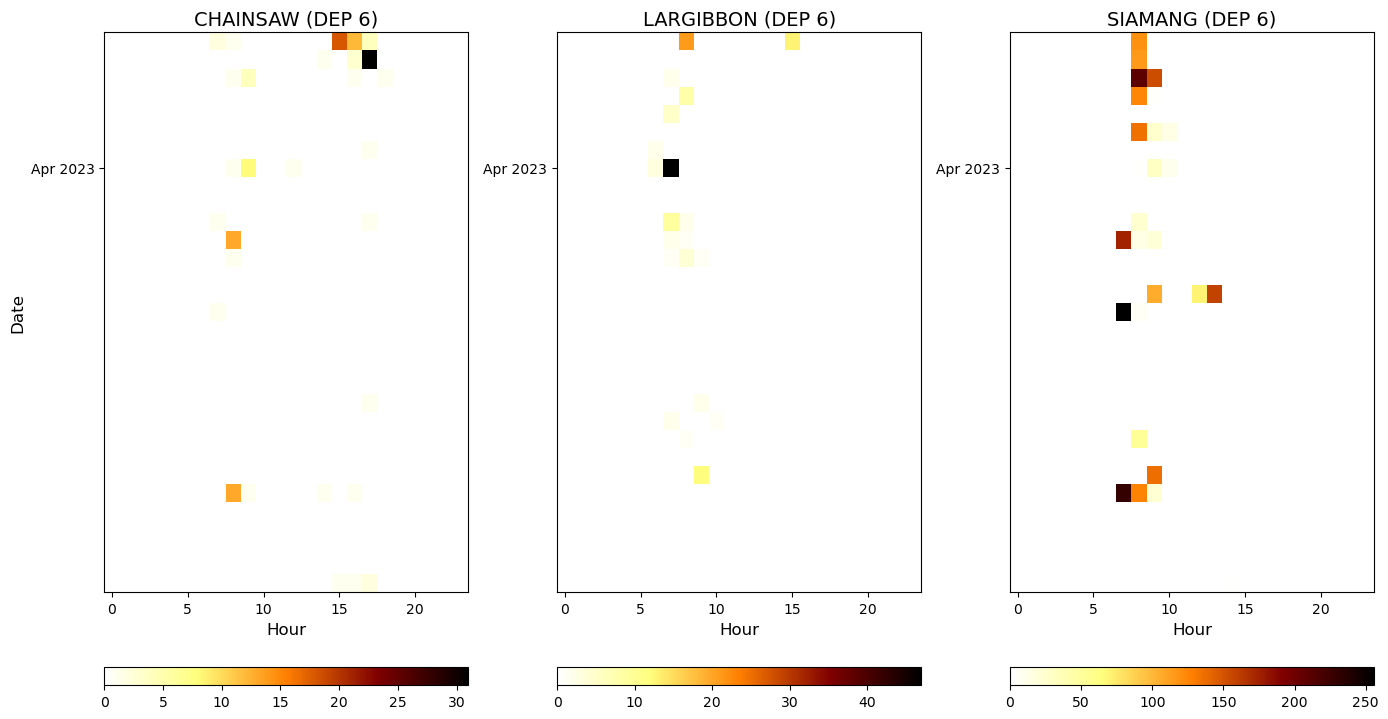

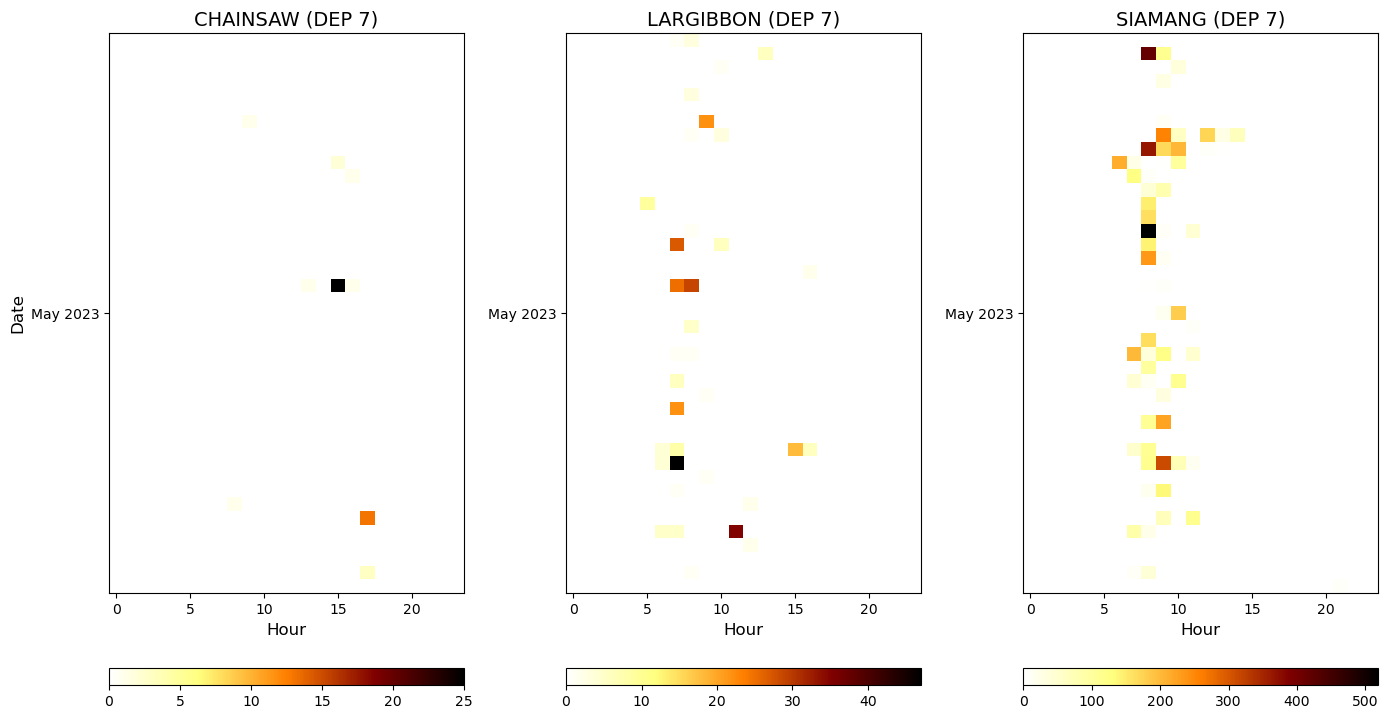

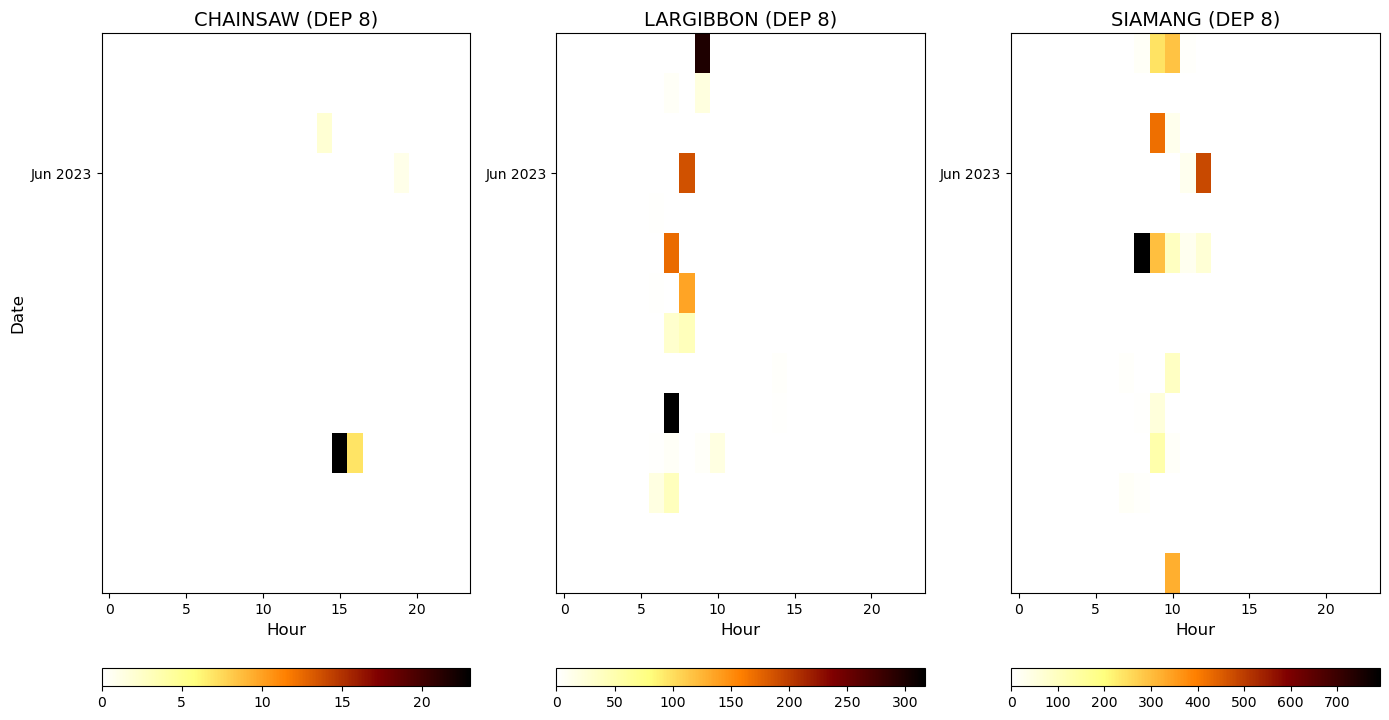

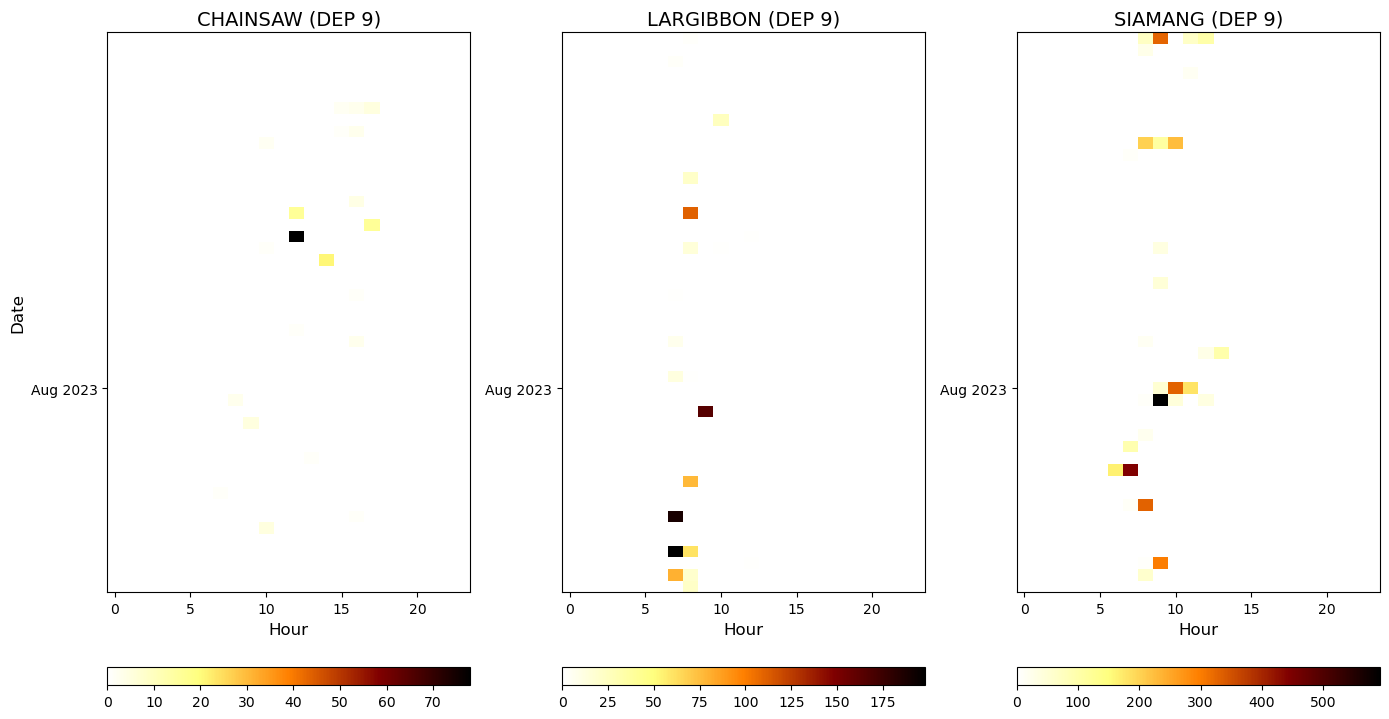

In [27]:
for dep in range(9):
    dielPlot(detections, deployment = 'DEP %d' % (dep+1))
    #plt.savefig('/Users/ivt2/Documents/2025/Jun/figures/diel_plot_dep_%d.png' % (dep+1), dpi=200)

2022-08-24 2023-08-31


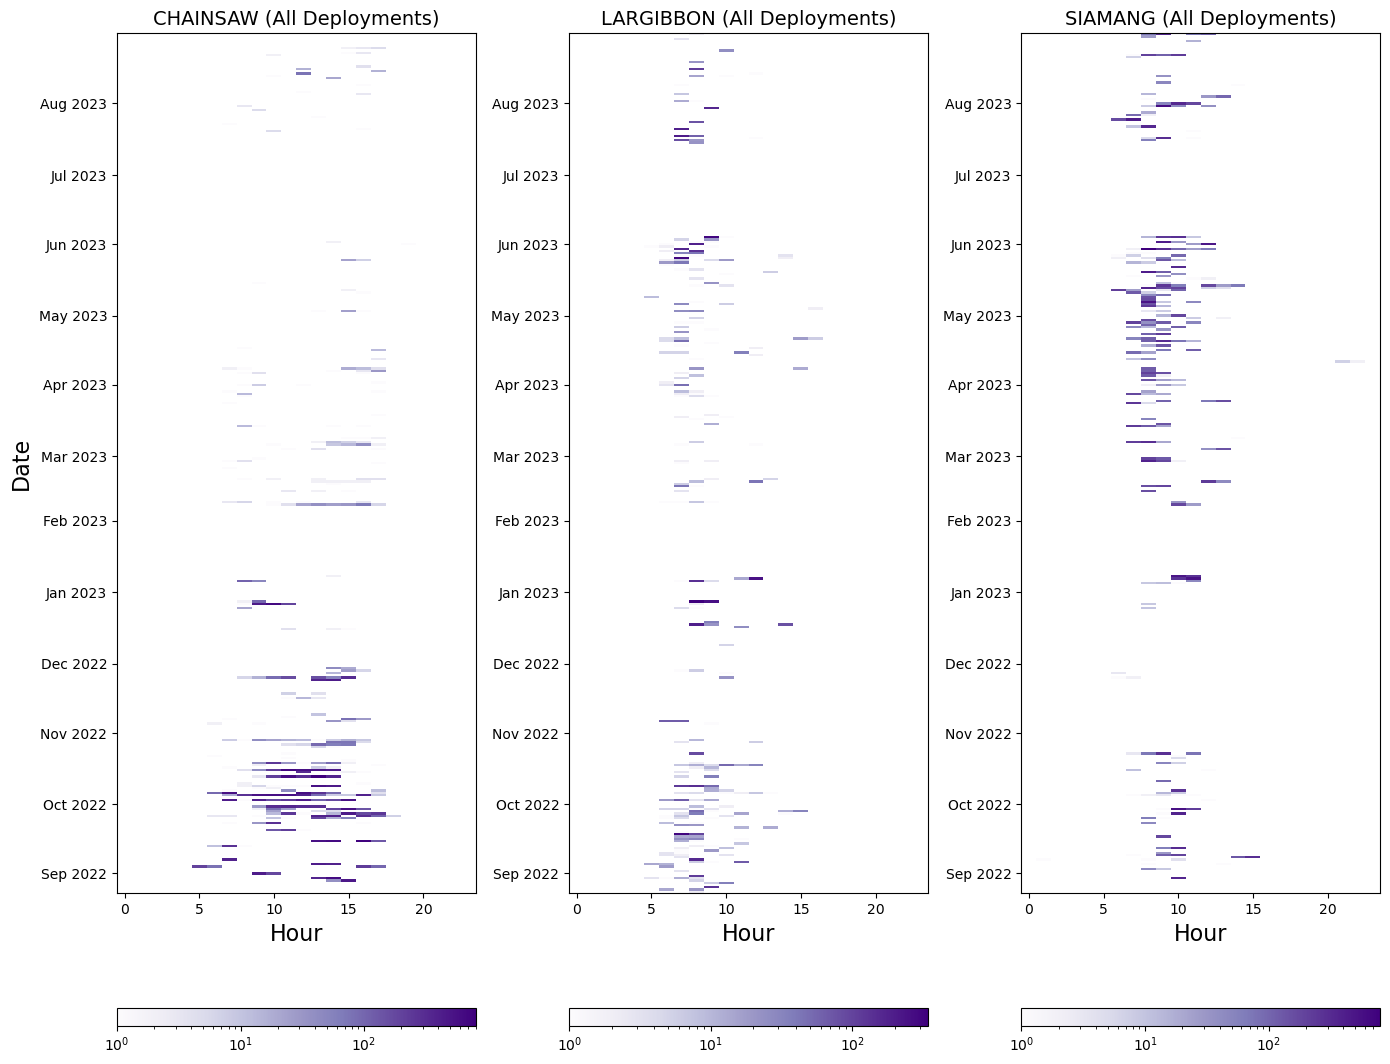

In [285]:
dielPlot(detections, vmaxes = [])
plt.savefig('E:/FINAL VERIFICATION/diel_plot_all_deps.png', dpi=200)

In [25]:
detections.head()

,Species,Deployment,Unit,Filename,Date,Start Time,End Time,Confidence,Positive or Negative,Point Name,LAT [decimal degrees],LON [decimal degrees],Y_PROJ,X_PROJ,First file date [UTC],Last file date [UTC],Total Days,Hour
0,CHAINSAW,DEP 1,Unit002,0.900_118_Unit002_20220901_092004_2073.0s_2076...,2022-09-01,2022-09-01 09:54:37,2022-09-01 09:54:40,0.900,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,9
1,CHAINSAW,DEP 1,Unit002,0.900_44_Unit002_20220901_092004_1923.0s_1926....,2022-09-01,2022-09-01 09:52:07,2022-09-01 09:52:10,0.900,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,9
2,CHAINSAW,DEP 1,Unit002,0.901_289_Unit002_20220920_104004_3036.0s_3039...,2022-09-20,2022-09-20 11:30:40,2022-09-20 11:30:43,0.901,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,11
3,CHAINSAW,DEP 1,Unit002,0.901_30_Unit002_20220829_144005_2022.0s_2025....,2022-08-29,2022-08-29 15:13:47,2022-08-29 15:13:50,0.901,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,15
4,CHAINSAW,DEP 1,Unit002,0.901_388_Unit002_20220901_092004_1023.0s_1026...,2022-09-01,2022-09-01 09:37:07,2022-09-01 09:37:10,0.901,Positive,U 2300,3.973692,98.063692,439278.3194,396056.5958,8/24/2022,9/22/2022,29,9


In [27]:
def dielVariabilityQuartiles(data, species):
    species_hour_date_counts = data[data['Species'] == species].groupby('Date')['Hour'].value_counts()
    species_hour_date_counts = species_hour_date_counts.unstack()
    species_hour_date_counts.fillna(0, inplace=True)

    medians = np.zeros(24)
    q25s = np.zeros(24)
    q75s = np.zeros(24)

    for hour in range(24):
        if hour in species_hour_date_counts.columns:
            medians[hour] = species_hour_date_counts[hour].quantile(0.5)
            q25s[hour] = species_hour_date_counts[hour].quantile(0.25)
            q75s[hour] = species_hour_date_counts[hour].quantile(0.75)
        else:
            medians[hour] = 0
            q25s[hour] = 0
            q75s[hour] = 0
    
    plt.figure(figsize=(6, 4))
    plt.fill_between(range(24), q25s, q75s, color='navy', alpha=0.2)
    plt.plot(range(24), medians, color='navy')
    plt.show()


In [29]:
def dielVariabilityMeans(data, species):
    species_hour_date_counts = data[data['Species'] == species].groupby('Date')['Hour'].value_counts()
    species_hour_date_counts = species_hour_date_counts.unstack()
    species_hour_date_counts.fillna(0, inplace=True)

    means = np.zeros(24)
    sds = np.zeros(24)

    for hour in range(24):
        if hour in species_hour_date_counts.columns:
            means[hour] = species_hour_date_counts[hour].mean()
            sds[hour] = species_hour_date_counts[hour].std()
        else:
            means[hour] = 0
            sds[hour] = 0
    
    plt.figure(figsize=(6, 4))
    plt.fill_between(range(24), means - sds, means + sds, color='navy', alpha=0.2)
    plt.plot(range(24), means, color='navy')
    plt.xlabel('Hour')
    plt.ylabel('Number of Detections Per Day')
    plt.title('Diel Variability of %s' % species)
    plt.show()


In [31]:
def dielVariabilityBoxplots(data, species):
    species_hour_date_counts = data[data['Species'] == species].groupby('Date')['Hour'].value_counts()
    species_hour_date_counts = species_hour_date_counts.unstack()
    species_hour_date_counts.fillna(0, inplace=True)
    for hour in range(24):
        if hour not in species_hour_date_counts.columns:
            species_hour_date_counts[hour] = 0
    flierprops = dict(marker='o',  # Circle marker
                  markerfacecolor='blue',  # Red fill color
                  markersize=4,  # Size of the marker
                  linestyle='none',  # Remove the connecting line
                  markeredgecolor='black')  # Border color
    species_hour_date_counts = species_hour_date_counts.sort_index(axis=1)
    #print(species_hour_date_counts.columns)
    plt.figure(figsize=(8, 4))
    species_hour_date_counts.boxplot(grid=True, color='navy', flierprops=flierprops)
    plt.xlabel('Hour')
    plt.ylabel('Number of Verified Detections')
    plt.title('Diel Variability of %s' % species)
    plt.show()

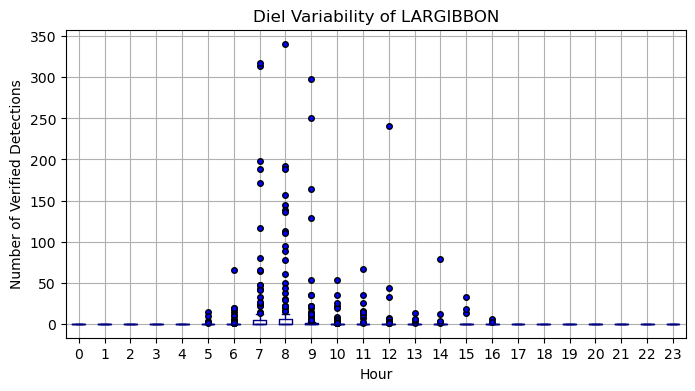

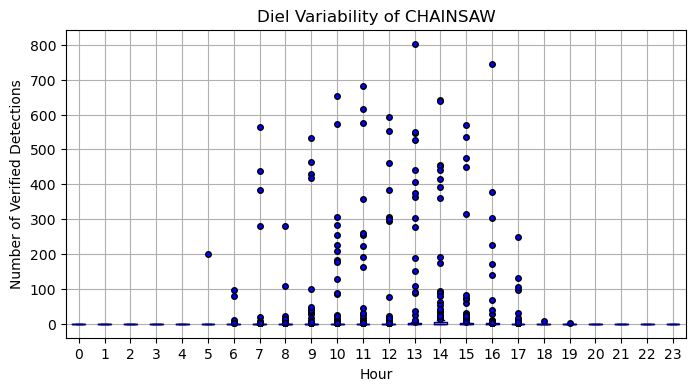

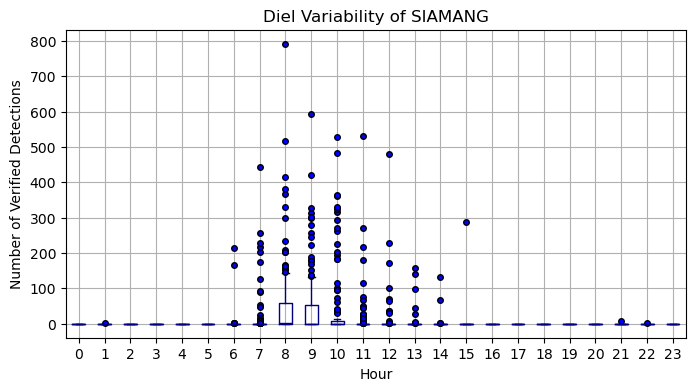

In [33]:
dielVariabilityBoxplots(detections, 'LARGIBBON')
dielVariabilityBoxplots(detections, 'CHAINSAW')
dielVariabilityBoxplots(detections, 'SIAMANG')

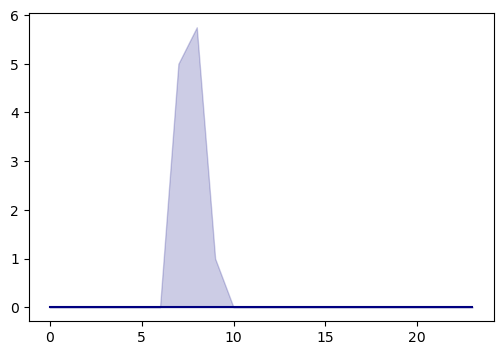

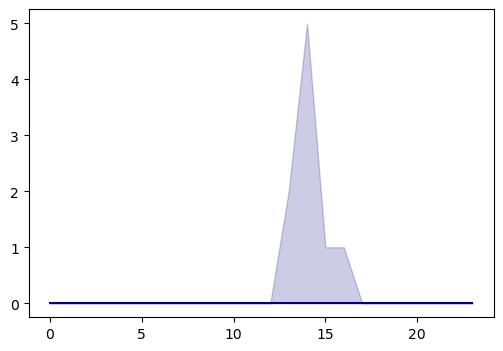

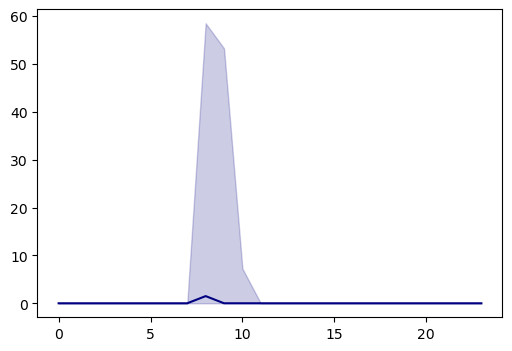

In [41]:
dielVariabilityQuartiles(detections, 'LARGIBBON')
dielVariabilityQuartiles(detections, 'CHAINSAW')
dielVariabilityQuartiles(detections, 'SIAMANG')

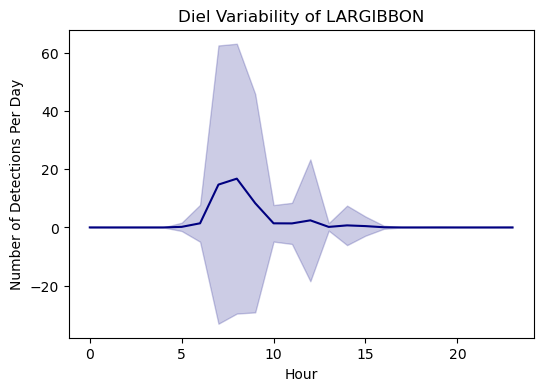

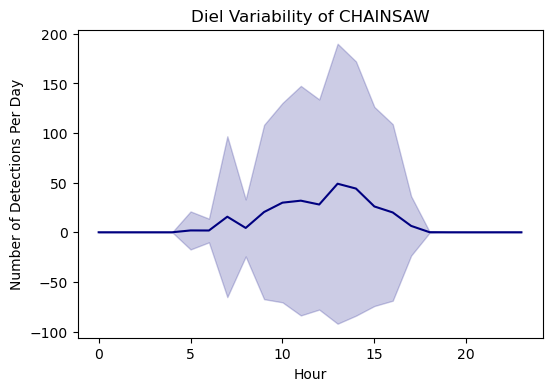

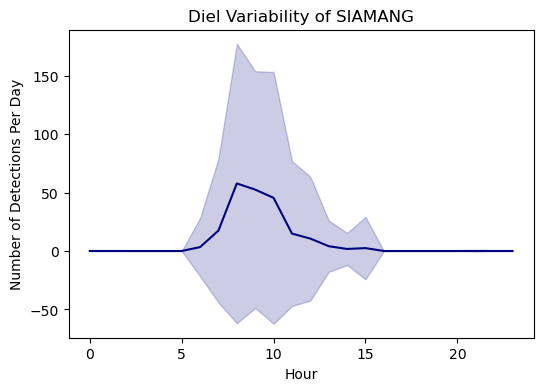

In [43]:
dielVariabilityMeans(detections, 'LARGIBBON')
dielVariabilityMeans(detections, 'CHAINSAW')
dielVariabilityMeans(detections, 'SIAMANG')

In [39]:
siamang_detections = detections[detections['Species'] == 'SIAMANG']
siamang_detections[siamang_detections['Hour'] > 21]
#Untuk mendapatkan deteksi yang ditentukan untuk waktu tertentu

,Species,Deployment,Unit,Filename,Date,Start Time,End Time,Confidence,Positive or Negative,Point Name,LAT [decimal degrees],LON [decimal degrees],Y_PROJ,X_PROJ,First file date [UTC],Last file date [UTC],Total Days,Hour
11287,SIAMANG,DEP 7,Unit003,0.986_2_Unit003_20230411_214340_1245.0s_1248.0...,2023-04-11,2023-04-11 22:04:25,2023-04-11 22:04:28,0.986,Positive,LP 300,3.954315,98.077281,437134.4253,397562.8844,4/11/2023,5/20/2023,39,22
11748,SIAMANG,DEP 7,Unit003,0.994_4_Unit003_20230411_214340_1215.0s_1218.0...,2023-04-11,2023-04-11 22:03:55,2023-04-11 22:03:58,0.994,Positive,LP 300,3.954315,98.077281,437134.4253,397562.8844,4/11/2023,5/20/2023,39,22


In [49]:
def dielVariabilityStripplots(data, species):
    species_hour_date_counts = data[data['Species'] == species].groupby('Date')['Hour'].value_counts()
    species_hour_date_counts = species_hour_date_counts.unstack()
    species_hour_date_counts.fillna(0, inplace=True)

    for hour in range(24):
        if hour not in species_hour_date_counts.columns:
            species_hour_date_counts[hour] = 0

    species_hour_date_counts = species_hour_date_counts.sort_index(axis=1)
    #print(species_hour_date_counts.columns)
    plt.figure(figsize=(8, 4))
    sn.stripplot(species_hour_date_counts)
    plt.xlabel('Hour')
    plt.ylabel('Number of Verified Detections')
    plt.title('Diel Variability of %s' % species)
    plt.show()

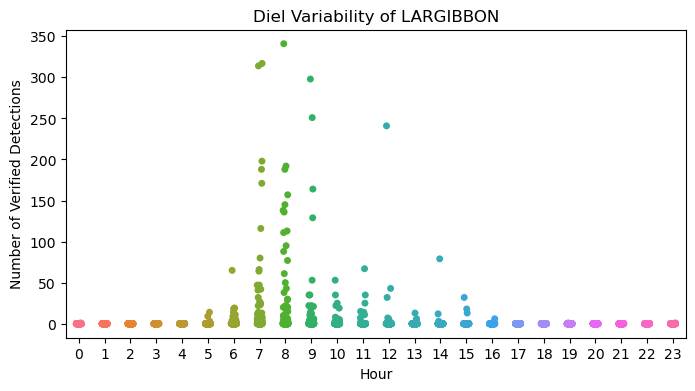

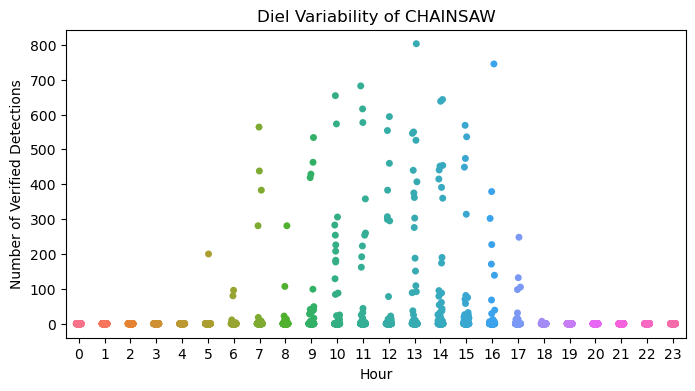

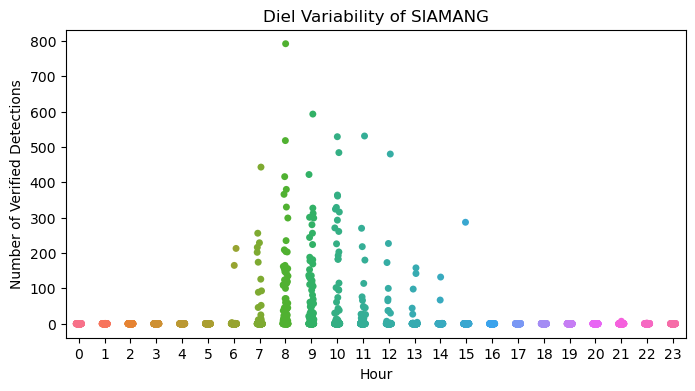

In [51]:
dielVariabilityStripplots(detections, 'LARGIBBON')
dielVariabilityStripplots(detections, 'CHAINSAW')
dielVariabilityStripplots(detections, 'SIAMANG')